In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df1=pd.read_csv("/content/funnel_data.csv")
df1

,user_id,step,timestamp
0,U133,signup_started,2026-07-20 04:19:00
1,U079,visited_site,2026-07-20 04:08:00
2,U079,email_verified,2026-07-20 04:20:00
3,U143,signup_started,2026-07-20 04:05:00
4,U035,details_filled,2026-07-20 04:28:00
...,...,...,...
537,U172,details_filled,2026-07-20 04:16:00
538,U027,details_filled,2026-07-20 04:06:00
539,U085,email_verified,2026-07-20 04:36:00
540,U119,signup_started,2026-07-20 04:10:00


In [ ]:
# df1.info()
# print(df1.head())
df1.shape

(542, 3)

In [ ]:
df1 = df1.drop_duplicates(subset=["user_id","step"])

dup_remove

,user_id,step,timestamp
0,U133,signup_started,2026-07-20 04:19:00
1,U079,visited_site,2026-07-20 04:08:00
2,U079,email_verified,2026-07-20 04:20:00
3,U143,signup_started,2026-07-20 04:05:00
4,U035,details_filled,2026-07-20 04:28:00
...,...,...,...
328,U132,purchase_completed,2026-07-20 05:09:00
374,U121,purchase_completed,2026-07-20 04:56:00
392,U133,purchase_completed,2026-07-20 04:59:00
473,U128,purchase_completed,2026-07-20 04:58:00


In [ ]:
funnel_order=["visited_site","signup_started","details_filled","email_verified","purchase_completed"]
funnel_order

['visited_site',
 'signup_started',
 'details_filled',
 'email_verified',
 'purchase_completed']

In [ ]:
df1["step"]=pd.Categorical(df1["step"],categories=funnel_order,ordered=True)
df1["step"]

,step
0,signup_started
1,visited_site
2,email_verified
3,signup_started
4,details_filled
...,...
537,details_filled
538,details_filled
539,email_verified
540,signup_started


In [ ]:
funnel=(df1.groupby("step")["user_id"].nunique().reset_index(name="users"))
funnel

/tmp/ipykernel_11209/2377274588.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  funnel=(df1.groupby("step")["user_id"].nunique().reset_index(name="users"))


,step,users
0,visited_site,200
1,signup_started,150
2,details_filled,96
3,email_verified,52
4,purchase_completed,44


In [ ]:
funnel = funnel.drop(columns=["Conversion Rate", "conversion Rate"], errors="ignore")
funnel["Conversion Rate"] = (funnel["users"] / funnel["users"].shift(1)) * 100
funnel.loc[0, "Conversion Rate"] = 100
funnel


,step,users,Drop-off Rate,Drop-off,Conversion Rate
0,visited_site,200,NaN,0.0,100.000000
1,signup_started,150,50.0,50.0,75.000000
2,details_filled,96,54.0,54.0,64.000000
3,email_verified,52,44.0,44.0,54.166667
4,purchase_completed,44,8.0,8.0,84.615385


In [ ]:
funnel["Drop-off"] = (
    funnel["users"].shift(1)
    -
    funnel["users"]
)

funnel.loc[0,"Drop-off"] = 0
funnel

,step,users,Drop-off Rate,Drop-off,Conversion Rate
0,visited_site,200,NaN,0.0,100.000000
1,signup_started,150,50.0,50.0,75.000000
2,details_filled,96,54.0,54.0,64.000000
3,email_verified,52,44.0,44.0,54.166667
4,purchase_completed,44,8.0,8.0,84.615385


In [ ]:
big_drop = funnel.loc[funnel["Drop-off"].idxmax()]
big_drop

,2
step,details_filled
users,96
Drop-off Rate,54.0
Drop-off,54.0
Conversion Rate,64.0


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<BarContainer object of 5 artists>

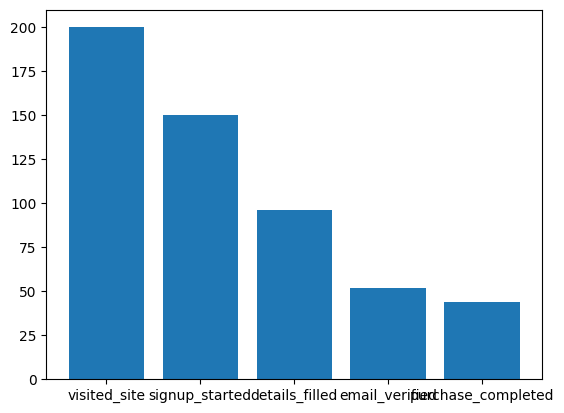

In [ ]:
plt.bar(funnel["step"], funnel["users"])

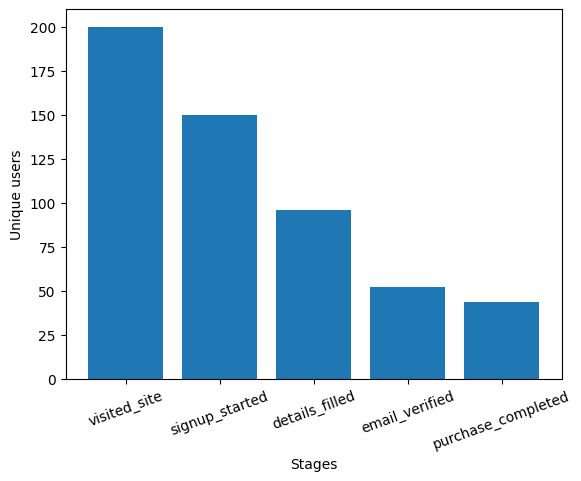

In [ ]:
plt.bar(funnel["step"], funnel["users"])
plt.xlabel("Stages")

plt.ylabel("Unique users")
plt.xticks(rotation=20)
plt.show()


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

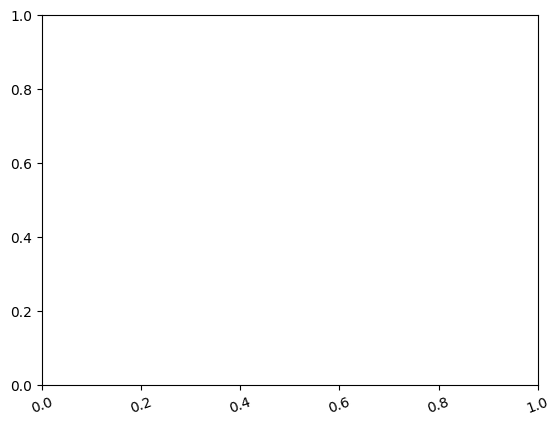

In [ ]:
plt.xticks(rotation=20)

In [ ]:
funnel

,step,users,Drop-off Rate,Drop-off,Conversion Rate
0,visited_site,200,NaN,0.0,100.000000
1,signup_started,150,50.0,50.0,75.000000
2,details_filled,96,54.0,54.0,64.000000
3,email_verified,52,44.0,44.0,54.166667
4,purchase_completed,44,8.0,8.0,84.615385


In [ ]:
Recommendation

The biggest drop-off occurs at the Email Verification stage.

Possible reasons:

• Verification email is delayed.
• Users don't receive OTP.
• Email lands in spam.
• Verification process is lengthy.

Suggested Improvement

Reduce verification friction by allowing social login, resending OTP instantly, and improving email delivery.